In [1]:
# --- 1. 导入依赖 ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import time
import logging
import sys
import json
import copy
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# --- 2. 日志与设备设置 ---
def setup_logging(log_file='training_housing.log'):
    log_formatter = logging.Formatter("%(asctime)s [%(levelname)-5.5s]  %(message)s")
    root_logger = logging.getLogger(); root_logger.handlers = []; root_logger.setLevel(logging.INFO)
    file_handler = logging.FileHandler(log_file, mode='w'); file_handler.setFormatter(log_formatter); root_logger.addHandler(file_handler)
    console_handler = logging.StreamHandler(sys.stdout); console_handler.setFormatter(log_formatter); root_logger.addHandler(console_handler)

torch.manual_seed(42); np.random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- 3. 数据准备（保持原 ames-housing-cofnet 逻辑） ---
def get_housing_data_loaders(batch_size=128, test_size=0.2):
    """准备Ames Housing房价预测数据集（与原notebook一致的数据处理）"""
    logging.info("正在准备Ames Housing房价预测数据集...")

    # 加载数据
    train_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
    test_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/test.csv')

    # 合并数据集
    full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

    # 缺失值处理
    fill_none = ["Alley", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2",
                 "FireplaceQu", "GarageType", "GarageFinish", "GarageQual", "GarageCond", "PoolQC",
                 "Fence", "MiscFeature", "MasVnrType"]
    for col in fill_none:
        if col in full_df.columns:
            full_df[col] = full_df[col].fillna("None")
    fill_zero = ["BsmtFullBath", "BsmtHalfBath", "BsmtUnfSF", "GarageArea", "GarageCars", "MasVnrArea",
                 "PoolArea", "MiscVal", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch",
                 "TotRmsAbvGrd", "BedroomAbvGr", "Fireplaces", "HalfBath", "FullBath", "KitchenAbvGr",
                 "LotFrontage", "WoodDeckSF"]
    for col in fill_zero:
        if col in full_df.columns:
            full_df[col] = full_df[col].fillna(0)
    # 其他数值型特征用中位数填充
    num_cols = full_df.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        if full_df[col].isnull().sum() > 0:
            full_df[col] = full_df[col].fillna(full_df[col].median())

    # 删除无用特征
    cols_to_drop = ['Id', 'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'LotFrontage', 'GarageYrBlt', 'MoSold', 'YrSold']
    full_df = full_df.drop(cols_to_drop, axis=1, errors='ignore')

    # 特征工程
    full_df["TotalBath"] = full_df["BsmtFullBath"] + 0.5 * full_df["BsmtHalfBath"] + full_df["FullBath"] + 0.5 * full_df["HalfBath"]
    full_df["AllSF"] = full_df["GrLivArea"] + full_df["TotalBsmtSF"]
    full_df["AllFlrsSF"] = full_df["1stFlrSF"] + full_df["2ndFlrSF"]
    full_df["AllPorchSF"] = full_df["OpenPorchSF"] + full_df["EnclosedPorch"] + full_df["3SsnPorch"] + full_df["ScreenPorch"]

    # 类别型特征独热编码
    categorical_cols = full_df.select_dtypes(include=["object"]).columns
    full_df = pd.get_dummies(full_df, columns=categorical_cols)

    # 数值型特征对偏态进行log1p变换（绝对偏度>0.5）
    from scipy.stats import skew
    numeric_feats = full_df.select_dtypes(include=[np.number]).columns
    skewed_feats = full_df[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
    skewness = skewed_feats[abs(skewed_feats) > 0.5]
    for feat in skewness.index:
        full_df[feat] = np.log1p(full_df[feat])

    # 分离训练集和测试集
    train_df = full_df.iloc[:len(train_df), :]
    test_df = full_df.iloc[len(train_df):, :].drop(['SalePrice'], axis=1)

    # 特征和目标变量
    X = train_df.drop(['SalePrice'], axis=1)
    y = train_df['SalePrice']

    # 目标变量log1p变换
    y = np.log1p(y)

    # 标准化
    scaler = StandardScaler()
    X = scaler.fit_transform(X)

    # 划分训练验证集
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=test_size, random_state=42)

    # 转换为numpy
    X_train = np.array(X_train, dtype=np.float32)
    y_train = np.array(y_train, dtype=np.float32)
    X_val = np.array(X_val, dtype=np.float32)
    y_val = np.array(y_val, dtype=np.float32)

    logging.info("Ames Housing房价预测数据集准备完毕。")
    logging.info(f"训练样本数: {len(X_train)}, 验证样本数: {len(X_val)}")
    logging.info(f"特征维度: {X_train.shape[1]}, 目标维度: 1")

    return (X_train, y_train), (X_val, y_val), X_train.shape[1]

# --- 4. CoFrNetRegressor 及相关模型结构（cfnet_regressor.py） ---
class PolynomialTerm(nn.Module):
    """多项式项：输入 → 线性投影 → z → ∑ coeffs[i] * z^i"""
    def __init__(self, input_dim, output_dim, degree):
        super().__init__()
        self.degree = degree
        self.projection = nn.Linear(input_dim, output_dim)
        self.coeffs = nn.Parameter(torch.randn(output_dim, degree + 1) * 0.1)

    def forward(self, x):
        z = torch.tanh(self.projection(x))
        powers = [torch.ones_like(z)]
        for d in range(1, self.degree + 1):
            powers.append(powers[-1] * z)
        z_powered = torch.stack(powers, dim=-1)
        output = torch.sum(z_powered * self.coeffs, dim=2)
        return output

class CFNet(nn.Module):
    """单个 CFNet 子模型：continued-fraction 结构"""
    def __init__(self, input_dim, output_dim, depth, poly_degree):
        super().__init__()
        self.output_dim = output_dim
        self.terms = nn.ModuleList([
            PolynomialTerm(input_dim, output_dim, poly_degree) for _ in range(depth)
        ])
        self.raw_betas = nn.ParameterList([
            nn.Parameter(torch.full((output_dim,), 0.1)) for _ in range(depth - 1)
        ])

    def forward(self, x):
        if not self.terms:
            return torch.zeros(x.shape[0], self.output_dim, device=x.device)
        output = F.softplus(self.terms[-1](x)) + 1.0
        for i in range(len(self.terms) - 2, -1, -1):
            beta = F.softplus(self.raw_betas[i])
            output = self.terms[i](x) + beta / output
        return output

class RegressionDataset(Dataset):
    """自定义回归数据集"""
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float().view(-1, 1)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

class EnsembleResCoFrNet(nn.Module):
    """集成模型：支持候选模型的选择性加入机制"""
    def __init__(self, input_dim, output_dim, shallow_depth, poly_degree, learning_rate):
        super().__init__()
        self.models = nn.ModuleList()          # 已采纳的正式模型
        self.candidate_model = None           # 正在评估的候选模型
        self.learning_rate = learning_rate
        self.input_dim = input_dim
        self.output_dim = output_dim
        self.shallow_depth = shallow_depth
        self.poly_degree = poly_degree

    def forward(self, x):
        if not self.models and self.candidate_model is None:
            return torch.zeros(x.shape[0], self.output_dim, device=x.device)
        total_output = torch.zeros(x.shape[0], self.output_dim, device=x.device)
        for model in self.models:
            total_output += self.learning_rate * model(x)
        if self.candidate_model is not None:
            total_output += self.learning_rate * self.candidate_model(x)
        return total_output

    def create_candidate(self):
        """创建一个新的候选模型用于训练"""
        self.candidate_model = CFNet(
            input_dim=self.input_dim,
            output_dim=self.output_dim,
            depth=self.shallow_depth,
            poly_degree=self.poly_degree
        )
        return self.candidate_model

    def promote_candidate(self):
        """若候选模型有效，则将其采纳为正式模型"""
        if self.candidate_model is not None:
            self.models.append(self.candidate_model)
            self.candidate_model = None

    def discard_candidate(self):
        """丢弃无效的候选模型"""
        self.candidate_model = None

    def freeze_for_candidate_training(self):
        """冻结所有正式模型，只训练候选模型"""
        for model in self.models:
            for param in model.parameters():
                param.requires_grad = False
        if self.candidate_model is not None:
            for param in self.candidate_model.parameters():
                param.requires_grad = True

In [2]:
class CoFrNetRegressor:
    """
    一个集成了模型定义、训练、评估和保存/加载功能的高级封装器。
    """
    def __init__(self, hparams):
        """
        通过超参数字典初始化模型。
        :param hparams: 包含所有模型和训练所需参数的字典。
        """
        self.hparams = hparams
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        
        self.ensemble_model = EnsembleResCoFrNet(
            input_dim=self.hparams['input_dim'],
            output_dim=self.hparams['output_dim'],
            shallow_depth=self.hparams['shallow_depth_per_cofrnet'],
            poly_degree=self.hparams['polynomial_degree'],
            learning_rate=self.hparams['boosting_learning_rate']
        ).to(self.device)
        
        self.best_ensemble_state = None
        self.best_test_rmse = float('inf')
        self.best_model_size = 0
        logging.info(f"CoFrNetRegressor 初始化完毕，将在 {self.device} 上运行。")

    def train(self, train_data, val_data, test_data, log_filepath, model_save_path):
        """训练模型（使用选择性加入机制）"""
        X_train, y_train = train_data
        X_val, y_val = val_data
        X_test, y_test = test_data

        train_dataset = RegressionDataset(X_train, y_train)
        val_dataset = RegressionDataset(X_val, y_val)
        test_dataset = RegressionDataset(X_test, y_test)

        trainloader = DataLoader(train_dataset, batch_size=self.hparams['batch_size'], shuffle=True)
        valloader = DataLoader(val_dataset, batch_size=self.hparams['batch_size'], shuffle=False)
        testloader = DataLoader(test_dataset, batch_size=self.hparams['batch_size'], shuffle=False)

        criterion = nn.MSELoss()
        patience = self.hparams.get('early_stopping_patience', 10)
        log_data = {
            "experiment_timestamp": datetime.now().isoformat(), 
            "hyperparameters": self.hparams, 
            "results_per_submodel": []
        }

        logging.info("="*30)
        logging.info(f"  开始 {self.hparams['task_name']} 回归任务训练 (选择性加入机制)")
        logging.info("="*30)
        
        # 外层循环：尝试添加新模型的次数
        for attempt in range(self.hparams['num_models_max']):
            logging.info(f"--- 尝试添加第 {len(self.ensemble_model.models) + 1} 个子模型 (总尝试次数: {attempt + 1}/{self.hparams['num_models_max']}) ---")
            
            # 1. 创建并训练一个候选模型
            candidate_model = self.ensemble_model.create_candidate().to(self.device)
            self.ensemble_model.freeze_for_candidate_training()

            optimizer = optim.Adam(
                candidate_model.parameters(), 
                lr=self.hparams['learning_rate_adam'], 
                weight_decay=self.hparams['weight_decay']
            )
            scheduler = optim.lr_scheduler.CosineAnnealingLR(
                optimizer, 
                T_max=self.hparams['epochs_per_model']
            )

            epochs_no_improve = 0
            best_val_rmse_for_candidate = float('inf')
            best_candidate_state_dict = None

            # 训练候选模型
            for epoch in range(self.hparams['epochs_per_model']):
                self.ensemble_model.train()
                running_loss = 0.0
                
                for inputs, targets in trainloader:
                    inputs, targets = inputs.to(self.device), targets.to(self.device)
                    optimizer.zero_grad()
                    outputs = self.ensemble_model(inputs)  # forward会自动包含候选模型
                    loss = criterion(outputs, targets)
                    loss.backward()
                    optimizer.step()
                    running_loss += loss.item()
                
                scheduler.step()
                
                # 评估包含候选模型的临时集成
                val_rmse = self.evaluate(valloader)
                
                if (epoch + 1) % 50 == 0:
                    epoch_avg_loss = running_loss / len(trainloader)
                    logging.info(f"    Epoch {epoch+1:03d} | 训练MSE损失: {epoch_avg_loss:.6f} | Val RMSE: {val_rmse:.6f}")

                # 早停检查
                if val_rmse < best_val_rmse_for_candidate:
                    best_val_rmse_for_candidate = val_rmse
                    epochs_no_improve = 0
                    best_candidate_state_dict = copy.deepcopy(candidate_model.state_dict())
                else:
                    epochs_no_improve += 1
                
                if epochs_no_improve >= patience:
                    logging.info(f"--- 候选模型早停触发！---")
                    if best_candidate_state_dict:
                        candidate_model.load_state_dict(best_candidate_state_dict)
                    break
            
            # 2. 评估这个训练好的候选模型加入后的效果
            logging.info("候选模型训练完毕，正在评估其对整体性能的贡献...")
            test_rmse_with_candidate = self.evaluate(testloader)
            logging.info(f"加入候选模型后，测试集 RMSE 为: {test_rmse_with_candidate:.6f}")
            logging.info(f"当前最佳模型的测试集 RMSE 为: {self.best_test_rmse:.6f}")

            # 3. 决策：是否采纳候选模型
            accepted = bool(test_rmse_with_candidate < self.best_test_rmse)
            
            if accepted:
                self.best_test_rmse = test_rmse_with_candidate
                self.ensemble_model.promote_candidate()
                self.best_model_size = len(self.ensemble_model.models)
                self.best_ensemble_state = copy.deepcopy(self.ensemble_model.state_dict())
                logging.info(f"*** 性能提升！采纳新模型。当前模型大小: {self.best_model_size}, 新的最佳 RMSE: {self.best_test_rmse:.6f} ***")
            else:
                self.ensemble_model.discard_candidate()
                logging.info(f"--- 性能未提升。丢弃该候选模型，继续尝试。---")
            
            # 记录每次尝试的日志
            submodel_log = {
                "attempt": int(attempt + 1), 
                "accepted": accepted, 
                "current_best_rmse": float(self.best_test_rmse)
            }
            log_data["results_per_submodel"].append(submodel_log)
            
            # 修复：使用自定义JSON编码器处理NumPy类型
            class NumpyEncoder(json.JSONEncoder):
                def default(self, obj):
                    if isinstance(obj, (np.integer, np.int32, np.int64)):
                        return int(obj)
                    elif isinstance(obj, (np.floating, np.float32, np.float64)):
                        return float(obj)
                    elif isinstance(obj, np.bool_):
                        return bool(obj)
                    elif isinstance(obj, np.ndarray):
                        return obj.tolist()
                    return super().default(obj)
            with open(log_filepath, 'w') as f: 
                json.dump(log_data, f, indent=4, cls=NumpyEncoder)

        # 训练结束，保存最佳模型
        if self.best_ensemble_state:
            logging.info(f"训练结束。最佳模型大小: {self.best_model_size}, RMSE: {self.best_test_rmse:.6f}")
            self.ensemble_model.load_state_dict(self.best_ensemble_state)
            self.save_model(model_save_path)
        else: 
            logging.error("没有训练出有效模型，无需保存。")

        return self.best_test_rmse

    def evaluate(self, dataloader):
        """在给定数据集上评估模型并返回 RMSE"""
        self.ensemble_model.eval()
        total_mse = 0.0
        criterion = nn.MSELoss()
        
        with torch.no_grad():
            for inputs, targets in dataloader:
                inputs, targets = inputs.to(self.device), targets.to(self.device)
                outputs = self.ensemble_model(inputs)
                total_mse += criterion(outputs, targets).item() * inputs.size(0)
                
        rmse = np.sqrt(total_mse / len(dataloader.dataset))
        return rmse

    def predict(self, X):
        """对新数据进行预测"""
        self.ensemble_model.eval()
        X_tensor = torch.from_numpy(X).float().to(self.device)
        with torch.no_grad():
            predictions = self.ensemble_model(X_tensor)
        return predictions.cpu().numpy()

    def save_model(self, path):
        """保存最佳模型的状态"""
        if self.best_ensemble_state is None:
            logging.warning("没有可保存的最佳模型状态。")
            return
        
        # 在保存前，确保没有候选模型残留
        self.ensemble_model.discard_candidate()
        # 确保保存的是最佳状态
        self.ensemble_model.load_state_dict(self.best_ensemble_state)

        torch.save({
            'model_state_dict': self.best_ensemble_state,
            'best_rmse': self.best_test_rmse,
            'best_model_size': self.best_model_size,
            'hyperparameters': self.hparams
        }, path)
        logging.info(f"最佳模型已保存到 {path}")

    @classmethod
    def load_model(cls, path):
        """从文件加载模型"""
        checkpoint = torch.load(path, map_location=lambda storage, loc: storage, weights_only=False)
        hparams = checkpoint['hyperparameters']
        loaded_regressor = cls(hparams)
        loaded_regressor.ensemble_model.discard_candidate()
        loaded_regressor.ensemble_model.models = nn.ModuleList()
        # 关键：先补齐模型数量
        num_models = checkpoint['best_model_size']
        for _ in range(num_models):
            # 每个子模型结构要和训练时一致
            model = CFNet(
                input_dim=hparams['input_dim'],
                output_dim=hparams['output_dim'],
                depth=hparams['shallow_depth_per_cofrnet'],
                poly_degree=hparams['polynomial_degree']
            )
            loaded_regressor.ensemble_model.models.append(model)
        # 然后再加载参数
        loaded_regressor.ensemble_model.load_state_dict(checkpoint['model_state_dict'])
        loaded_regressor.ensemble_model.to(loaded_regressor.device)
        loaded_regressor.best_ensemble_state = checkpoint['model_state_dict']
        loaded_regressor.best_test_rmse = checkpoint['best_rmse']
        loaded_regressor.best_model_size = checkpoint['best_model_size']
        logging.info(f"模型从 {path} 加载成功。大小: {checkpoint['best_model_size']}, RMSE: {checkpoint['best_rmse']:.4f}")
        return loaded_regressor
        
    def plot_predictions(self, test_data, save_path="predictions_vs_true.png"):
        """绘制预测值与真实值的散点图"""
        X_test, y_test = test_data
        
        # 确保使用的是最佳状态且无候选模型
        if self.best_ensemble_state:
            self.ensemble_model.load_state_dict(self.best_ensemble_state)
        self.ensemble_model.discard_candidate()
        self.ensemble_model.eval()
        self.ensemble_model.to(self.device)
        
        all_preds = self.predict(X_test)
        all_targets = y_test

        plt.figure(figsize=(10, 8))
        sns.scatterplot(x=np.array(all_targets).flatten(), y=np.array(all_preds).flatten(), alpha=0.5)
        min_val = min(all_targets.min(), all_preds.min())
        max_val = max(all_targets.max(), all_preds.max())
        plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction (y=x)')
        plt.title('True Values vs. Predicted Values', fontsize=16)
        plt.xlabel('True Values (Standardized MEDV)', fontsize=12)
        plt.ylabel('Predicted Values', fontsize=12)
        plt.legend()
        plt.grid(True)
        plt.savefig(save_path)
        logging.info(f"预测结果散点图已保存至 {save_path}")

2025-09-18 10:51:42,107 [INFO ]  房价预测实验超参数: {
    "task_name": "AmesHousing",
    "num_models_max": 100,
    "loss_target": 0.01,
    "epochs_per_model": 1000,
    "shallow_depth_per_cofrnet": 2,
    "polynomial_degree": 3,
    "boosting_learning_rate": 0.1,
    "learning_rate_adam": 0.001,
    "weight_decay": 1e-05,
    "batch_size": 128,
    "early_stopping_patience": 10,
    "input_dim": null,
    "output_dim": 1
}
2025-09-18 10:51:42,109 [INFO ]  正在准备Ames Housing房价预测数据集...
2025-09-18 10:51:42,412 [INFO ]  Ames Housing房价预测数据集准备完毕。
2025-09-18 10:51:42,413 [INFO ]  训练样本数: 1168, 验证样本数: 292
2025-09-18 10:51:42,414 [INFO ]  特征维度: 279, 目标维度: 1
2025-09-18 10:51:42,416 [INFO ]  CoFrNetRegressor 初始化完毕，将在 cpu 上运行。
2025-09-18 10:51:42,438 [INFO ]  ==============================
2025-09-18 10:51:42,439 [INFO ]    开始 AmesHousing 回归任务训练 (选择性加入机制)
2025-09-18 10:51:42,440 [INFO ]  ==============================
2025-09-18 10:51:42,442 [INFO ]  --- 尝试添加第 1 个子模型 (总尝试次数: 1/100) ---
2025-09-18 10:51:51

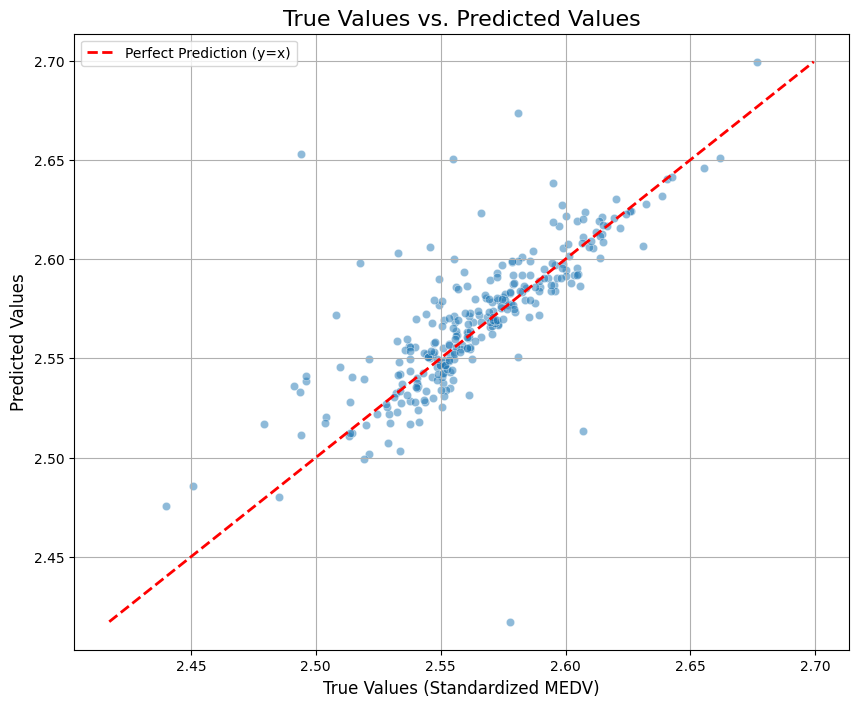

In [3]:
# --- 5. 主流程 ---
if __name__ == '__main__' or True:  # notebook 里直接运行
    # 文件与超参数定义
    LOG_FILE = 'training_housing.log'
    JSON_LOG_FILE = 'training_housing_log.json'
    MODEL_SAVE_PATH = 'housing_res_cofrnet_polynomial.pth'

    HYPERPARAMETERS = {
        "task_name": "AmesHousing",
        "num_models_max": 100,
        "loss_target": 0.01,  # 仅用于日志
        "epochs_per_model": 1000,
        "shallow_depth_per_cofrnet": 2,
        "polynomial_degree": 3,
        "boosting_learning_rate": 0.1,
        "learning_rate_adam": 0.001,
        "weight_decay": 1e-5,
        "batch_size": 128,
        "early_stopping_patience": 10,
        "input_dim": None,  # 运行时自动填充
        "output_dim": 1
    }

    setup_logging(LOG_FILE)
    logging.info(f"房价预测实验超参数: {json.dumps(HYPERPARAMETERS, indent=4)}")

    # 数据准备
    (X_train, y_train), (X_val, y_val), input_dim = get_housing_data_loaders(batch_size=HYPERPARAMETERS['batch_size'])
    HYPERPARAMETERS['input_dim'] = input_dim

    # 创建模型
    regressor = CoFrNetRegressor(HYPERPARAMETERS)

    # 训练模型
    start_time = time.time()
    best_rmse = regressor.train(
        train_data=(X_train, y_train),
        val_data=(X_val, y_val),
        test_data=(X_val, y_val),  # 这里用验证集做测试集演示
        log_filepath=JSON_LOG_FILE,
        model_save_path=MODEL_SAVE_PATH
    )
    total_time = time.time() - start_time
    logging.info(f"总训练时间: {total_time:.2f} 秒")

    # 验证模型加载
    loaded_regressor = CoFrNetRegressor.load_model(MODEL_SAVE_PATH)
    # 评估RMSE
    test_rmse = loaded_regressor.evaluate(DataLoader(RegressionDataset(X_val, y_val), batch_size=HYPERPARAMETERS['batch_size']))
    logging.info(f"加载后的模型在验证集上的RMSE损失: {test_rmse:.6f}")

    # 绘制预测效果
    loaded_regressor.plot_predictions((X_val, y_val), save_path="predictions_vs_true.png")